In [1]:
from wrapper import BasicEnvironmentRGB, DomainRandomization, RandomColorReplace
import gymnasium as gym
from gymnasium.wrappers import FrameStackObservation, TransformObservation, ResizeObservation
from matplotlib import pyplot as plt
from rltesting.torch_rl.utils import random_sample_single_env
from rltesting.torch_rl.buffers import ReplayBuffer
from rltesting.torch_rl.models import MLP
from rltesting.utils.torch_utils import EarlyStopping
from fvd_models import Encoder, Decoder, AEVAE
import numpy as np
import torch
import skdim
import os

/home/antony/anaconda3/envs/rltesting/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
/home/antony/anaconda3/envs/rltesting/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
/home/antony/anaconda3/envs/rltesting/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resour

Obs shape: (16, 4, 84, 84), dtype: uint8, range: [0, 255]
Using cuda device


KeyboardInterrupt: 

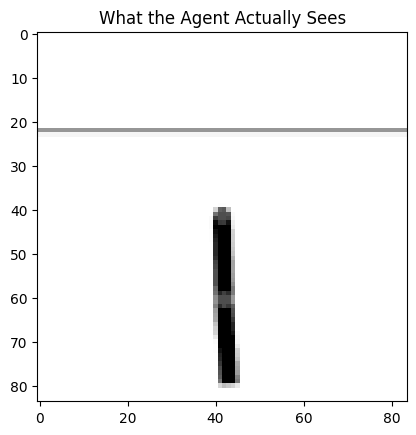

In [ ]:
# ---- PPO on grayscale images, Atari-style (framestack 4) ---- #
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecTransposeImage, VecFrameStack, SubprocVecEnv 
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.atari_wrappers import AtariWrapper
import gymnasium as gym
from gymnasium.wrappers import ResizeObservation, TransformObservation, GrayscaleObservation
from stable_baselines3.common.monitor import Monitor

class RewardLogger(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_returns = []
        self.episode_timesteps = []  # <--- NEW: List to store the steps

    def _on_step(self):
        for info in self.locals.get('infos', []):
            if 'episode' in info:
                # Save the reward
                self.episode_returns.append(info['episode']['r'])
                # Save the exact timestep when this episode finished
                self.episode_timesteps.append(self.num_timesteps) 
        return True

def make_gray_image_env():
    e = gym.make('Acrobot-v1', render_mode='rgb_array')
    e = BasicEnvironmentRGB(e)
    e = ResizeObservation(e, (84, 84))
    e = GrayscaleObservation(e, keep_dim=True)
    e = Monitor(e)  # add this
    return e

# VecFrameStack handles framestacking at the vec level — cleaner for SB3
ppo_img_env = SubprocVecEnv([make_gray_image_env for _ in range(16)])
ppo_img_env = VecFrameStack(ppo_img_env, n_stack=4)
ppo_img_env = VecTransposeImage(ppo_img_env)

# Verify shapes
obs = ppo_img_env.reset()
print(f"Obs shape: {obs.shape}, dtype: {obs.dtype}, range: [{obs.min()}, {obs.max()}]")
# Should be (4, 4, 84, 84) — 4 envs, 4 grayscale frames, 84x84

# Grab a batch of observations
test_obs = ppo_img_env.reset()

# test_obs is shape (16, 4, 84, 84). 
# Let's look at the first environment (0) and the most recent frame (-1)
sample_frame = test_obs[0, -1, :, :] 

plt.imshow(sample_frame, cmap='gray')
plt.title("What the Agent Actually Sees")
plt.savefig("agent_vision_test.png")

policy_kwargs = dict(
    share_features_extractor=False
)

ppo_img = PPO(
    'CnnPolicy', 
    ppo_img_env, 
    verbose=1,
    n_steps=128,          # Buffer size = n_steps * n_envs = 128 * 16 = 2048
    batch_size=256,       # 2048 / 256 = 8 minibatches per epoch
    n_epochs=8,           # Fewer epochs to prevent CNN overfitting
    learning_rate=1e-4, # Standard for Nature CNN 
    clip_range=0.1,       # Tighter clipping for stability
    ent_coef=0.02,        # CRITICAL: Forces exploration to build momentum
    policy_kwargs=policy_kwargs,
    vf_coef=0.5           # Standard value, keeps value loss in check
)

img_logger = RewardLogger()
ppo_img = ppo_img.learn(total_timesteps=1_000_000, callback=img_logger)

# Evaluate
img_eval_env = DummyVecEnv([make_gray_image_env])
img_eval_env = VecFrameStack(img_eval_env, n_stack=4)
img_eval_env = VecTransposeImage(img_eval_env)

ppo_img_returns = []
obs = img_eval_env.reset()
for _ in range(10):
    obs = img_eval_env.reset()
    total = 0
    while True:
        action, _ = ppo_img.predict(obs, deterministic=True)
        obs, r, done, info = img_eval_env.step(action)
        total += r[0]
        if done[0]:
            break
    ppo_img_returns.append(total)

print(f"PPO Images | Mean: {np.mean(ppo_img_returns):.1f} | Std: {np.std(ppo_img_returns):.1f}")

fig, ax = plt.subplots(figsize=(8, 4))

# 1. Plot the raw data using timesteps for the x-axis
ax.plot(img_logger.episode_timesteps, img_logger.episode_returns, alpha=0.3, label='Raw')

# 2. Plot the smoothed data
if len(img_logger.episode_returns) > 50:
    window = 50
    # Calculate the moving average
    smoothed = np.convolve(img_logger.episode_returns, np.ones(window)/window, mode='valid')
    
    # Slice the timesteps array to match the length of the smoothed array
    # We align the smoothed point with the *end* of the window
    smoothed_timesteps = img_logger.episode_timesteps[window-1:]
    
    # Plot smoothed line against the aligned timesteps
    ax.plot(smoothed_timesteps, smoothed, label=f'{window}-ep avg', color='orange')

# 3. Update the labels
ax.set_xlabel('Environment Steps')  # <--- Updated label
ax.set_ylabel('Return')
ax.set_title('PPO Images (Grayscale, Framestack 4) - Training Curve')
ax.legend()

plt.tight_layout()
plt.show()

In [13]:
def print_model_parameters(model):
    # Total and trainable parameters
    total_params = sum(p.numel() for p in model.policy.parameters())
    trainable_params = sum(p.numel() for p in model.policy.parameters() if p.requires_grad)
    
    print(f"Total Parameters:     {total_params:,}")
    print(f"Trainable Parameters: {trainable_params:,}")
    print("-" * 30)
    
    # Breakdown by major components
    # 1. Feature Extractor (The CNN)
    if hasattr(model.policy, 'features_extractor'):
        cnn_params = sum(p.numel() for p in model.policy.features_extractor.parameters())
        print(f"Feature Extractor (Shared CNN): {cnn_params:,}")
    
    # If you unshared the features extractor, these will exist:
    if hasattr(model.policy, 'pi_features_extractor') and model.policy.pi_features_extractor is not model.policy.features_extractor:
         pi_cnn_params = sum(p.numel() for p in model.policy.pi_features_extractor.parameters())
         print(f"Actor CNN (Unshared): {pi_cnn_params:,}")
         
    if hasattr(model.policy, 'vf_features_extractor') and model.policy.vf_features_extractor is not model.policy.features_extractor:
         vf_cnn_params = sum(p.numel() for p in model.policy.vf_features_extractor.parameters())
         print(f"Critic CNN (Unshared): {vf_cnn_params:,}")

    # 2. Action Network (Actor head)
    if hasattr(model.policy, 'action_net'):
        actor_params = sum(p.numel() for p in model.policy.action_net.parameters())
        print(f"Action Net (Actor head): {actor_params:,}")

    # 3. Value Network (Critic head)
    if hasattr(model.policy, 'value_net'):
        critic_params = sum(p.numel() for p in model.policy.value_net.parameters())
        print(f"Value Net (Critic head): {critic_params:,}")


# Call it on your trained or newly initialized model
print_model_parameters(ppo_img)

Total Parameters:     3,370,308
Trainable Parameters: 3,370,308
------------------------------
Feature Extractor (Shared CNN): 1,684,128
Critic CNN (Unshared): 1,684,128
Action Net (Actor head): 1,539
Value Net (Critic head): 513


Using cuda device
-----------------------------
| time/              |      |
|    fps             | 6257 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 500         |
|    ep_rew_mean          | -500        |
| time/                   |             |
|    fps                  | 5856        |
|    iterations           | 2           |
|    time_elapsed         | 0           |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 8.79452e-05 |
|    clip_fraction        | 0           |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.1        |
|    explained_variance   | 0.00335     |
|    learning_rate        | 0.0003      |
|    loss                 | 87.8        |
|    n_updates            | 4           |
|    policy_grad

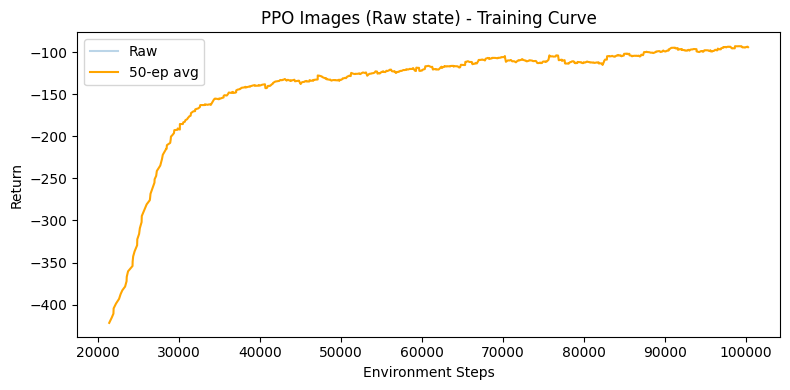

: 

In [ ]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import BaseCallback

ppo_raw_env = make_vec_env('Acrobot-v1', n_envs=4)
ppo_raw = PPO(
    "MlpPolicy",          # MUST be MlpPolicy for vector states
    ppo_raw_env,
    verbose=1,
    n_steps=256,          # Buffer size = 256 * 16 = 4096
    batch_size=256,       # 4096 / 256 = 16 minibatches per epoch
    n_epochs=4,           # 4 passes over the data
    learning_rate=3e-4,   # Standard, robust learning rate for MLPs
    gamma=0.99,           # Standard discount factor
    gae_lambda=0.94,      # Slightly lower lambda helps with Acrobot's delayed reward
    clip_range=0.2,       # Standard clipping
    ent_coef=0.0,         # MLPs usually solve Acrobot fine without forced entropy
    # vf_coef=0.5         # Default is fine here!
)

raw_logger = RewardLogger()
ppo_raw.learn(total_timesteps=100_000, callback=raw_logger)

# Evaluate
raw_eval_env = gym.make('Acrobot-v1')
ppo_raw_returns = []
for _ in range(10):
    obs, _ = raw_eval_env.reset()
    total = 0
    while True:
        action, _ = ppo_raw.predict(obs, deterministic=True)
        obs, r, term, trunc, _ = raw_eval_env.step(action)
        total += r
        if term or trunc:
            break
    ppo_raw_returns.append(total)

print(f"PPO Raw State | Mean: {np.mean(ppo_raw_returns):.1f} | Std: {np.std(ppo_raw_returns):.1f}")

fig, ax = plt.subplots(figsize=(8, 4))

# 1. Plot the raw data using timesteps for the x-axis
ax.plot(img_logger.episode_timesteps, img_logger.episode_returns, alpha=0.3, label='Raw')

# Plot training curve
if len(raw_logger.episode_returns) > 50:
    window = 50
    # Calculate the moving average
    smoothed = np.convolve(raw_logger.episode_returns, np.ones(window)/window, mode='valid')
    
    # Slice the timesteps array to match the length of the smoothed array
    # We align the smoothed point with the *end* of the window
    smoothed_timesteps = raw_logger.episode_timesteps[window-1:]
    
    # Plot smoothed line against the aligned timesteps
    ax.plot(smoothed_timesteps, smoothed, label=f'{window}-ep avg', color='orange')

# 3. Update the labels
ax.set_xlabel('Environment Steps')  # <--- Updated label
ax.set_ylabel('Return')
ax.set_title('PPO Images (Raw state) - Training Curve')
ax.legend()

plt.tight_layout()
plt.show()